# 📚 [LAB 12] 1. 단순선형회귀

In [1]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np

# 선형회귀를 위한 참조
from statsmodels.formula.api import ols

# 상관분석을 위한 참조
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, pearsonr, spearmanr

In [2]:
origin = load_data("cars")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab12_/cars.xlsx
[desc] 자동차의 속도(speed)에 따른 제동거리(dist) 조사 데이터 (출처: R 기본 데이터)

field    description
-------  -------------
speed    속도
dist     제동거리


===== 데이터 크기 확인 =====
데이터셋 크기: (50, 2)
열 개수: 2
행 개수: 50

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   speed   50 non-null     int64
 1   dist    50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes
None


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


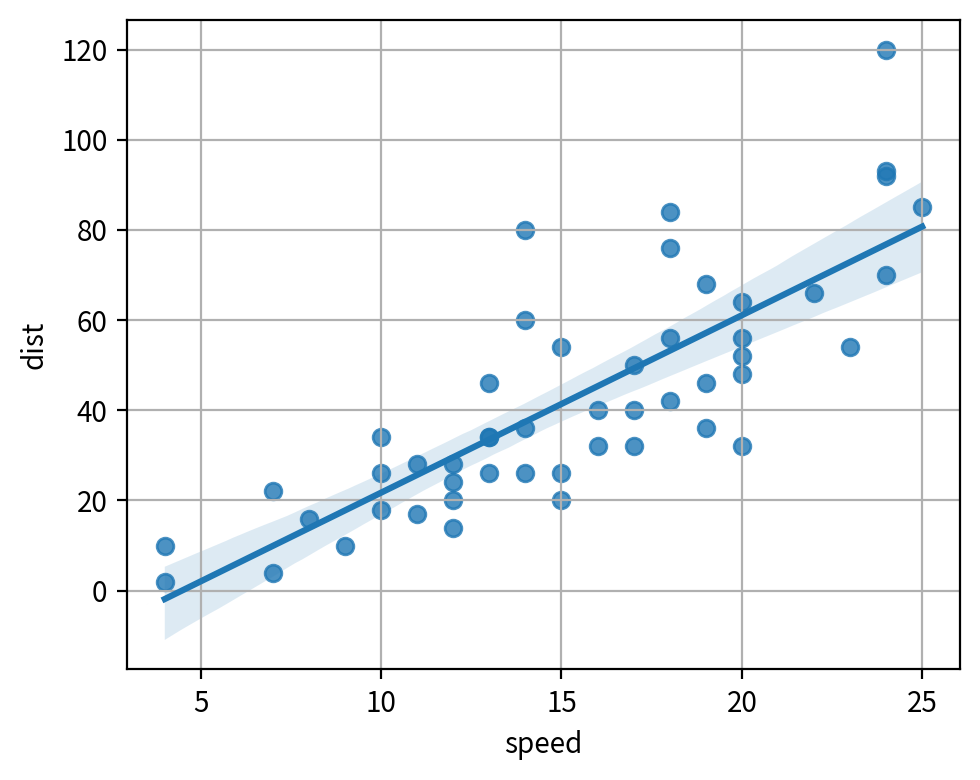

In [3]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1000
height_px = 800
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) 그래프 그리기 -> seaborn 사용
sb.regplot(data=origin, x="speed", y="dist")

# 3) 그래프 꾸미기
ax.grid(True)


plt.tight_layout()
plt.show()
plt.close()

Ramsey RESET Test : 선형성 적합 (p-value: 0.1364)


,original_skew,log_skew,outliers(|z|>3)
speed,-0.117510,-1.668586,0.0
dist,0.806895,-1.384501,1.0


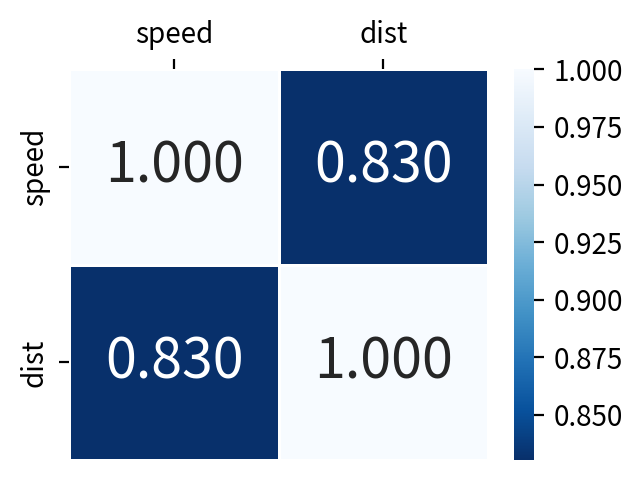

본 분석에서는 speed과 dist 간 상관관계를 검토하였다.

데이터 점검 과정에서 비선형 관계 가능성 또는 이상치 영향이 확인되어 스피어만 상관계수를 사용하였다.

분석 결과, 스피어만 상관계수는 r = 0.830, p = 0.000(으)로 나타나 두 변수 간 양의 단조 관계가 존재함을 확인하였다.


In [4]:
xname = "speed"
yname = "dist"

# ---------------------------------
# 선형성 가정 확인 (Ramsey RESET)
# ---------------------------------
x = origin[xname]
y = origin[yname]
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
reset = linear_reset(model, power=2, use_f=True)
# 선형성 적합 여부 (True=적합, False=부적합)
linearity_ok = reset.pvalue > 0.05
print(
    f"Ramsey RESET Test : {'선형성 적합' if linearity_ok else '선형성 위반'} (p-value: {reset.pvalue:.4f})"
)

# ---------------------------------
# 이상치와 왜도 검정
# ---------------------------------
data = origin[[xname, yname]]
results = {}

for col in data.columns:
    temp = data[col].dropna()
    # 왜도 계산
    skew_original = temp.skew()
    # Z-score 기반 이상치 탐지 (|z| > 3)
    z_scores = zscore(temp)
    outlier_count = int(np.sum(np.abs(z_scores) > 3))
    # 로그 변환 후 왜도 계산 (음수 대비 +1)
    data_log = np.log1p(temp - temp.min() + 1)
    skew_log = data_log.skew()

    results[col] = {
        "original_skew": skew_original,
        "log_skew": skew_log,
        "outliers(|z|>3)": outlier_count,
    }

results_df = DataFrame(results).T
display(results_df)

# 이상치 점검 결과
outlier_flag = (results_df["outliers(|z|>3)"] > 0).any()

# ---------------------------------
# 상관분석 + 보고서 텍스트 생성
# ---------------------------------
report = f"본 분석에서는 {xname}과 {yname} 간 상관관계를 검토하였다.\n\n"

if linearity_ok and not outlier_flag:
    chosen = "pearson"
    corr, pval = pearsonr(origin[xname], origin[yname])
    if pval > 0.05:
        report += "데이터 점검 결과, 두 변수의 관계는 통계적으로 유의하지 않았다."
    else:
        direction = "양의 상관" if corr > 0 else "음의 상관"
        report += (
            "데이터 점검 결과, 두 변수의 관계는 선형적이며 이상치의 영향도 크지 않아 피어슨 상관계수를 사용하였다.\n\n"
            f"분석 결과, 피어슨 상관계수는 r = {corr:0.3f}, p = {pval:0.3f}(으)로 나타나 두 변수 간 {direction} 관계가 통계적으로 유의함을 확인하였다."
        )
else:
    chosen = "spearman"
    corr, pval = spearmanr(origin[xname], origin[yname])
    if pval > 0.05:
        report += "데이터 점검 결과, 두 변수의 관계는 통계적으로 유의하지 않았다."
    else:
        direction = "양의 단조" if corr > 0 else "음의 단조"
        report += (
            "데이터 점검 과정에서 비선형 관계 가능성 또는 이상치 영향이 확인되어 스피어만 상관계수를 사용하였다.\n\n"
            f"분석 결과, 스피어만 상관계수는 r = {corr:0.3f}, p = {pval:0.3f}(으)로 나타나 두 변수 간 {direction} 관계가 존재함을 확인하였다."
        )

# ---------------------------------
# 결과 시각화 (상관행렬 히트맵)
# ---------------------------------
corr_matrix = origin[[xname, yname]].corr(method=chosen)

# 1) 그래프 초기화
width_px = 650  # 그래프 가로 크기
height_px = 500  # 그래프 세로 크기
rows = 1  # 그래프 행 수
cols = 1  # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) heatmap 그리기
sb.heatmap(
    data=corr_matrix,
    annot=True,
    fmt="0.3f",
    linewidth=0.5,
    cmap="Blues_r",
    annot_kws={"size": 20},
)

# 3) 그래프 꾸미기
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top()  # x축의 변수 이름을 상단으로 이동

# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

# ---------------------------------
# 결과 보고 출력
# ---------------------------------
print(report)

In [5]:
x = origin[["speed"]]
x

,speed
0,4
1,4
2,7
3,7
4,8
5,9
6,10
7,10
8,10
9,11


In [6]:
y = origin["dist"]
y

0       2
1      10
2       4
3      22
4      16
5      10
6      18
7      26
8      34
9      17
10     28
11     14
12     20
13     24
14     28
15     26
16     34
17     34
18     46
19     26
20     36
21     60
22     80
23     20
24     26
25     54
26     32
27     40
28     32
29     40
30     50
31     42
32     56
33     76
34     84
35     36
36     46
37     68
38     32
39     48
40     52
41     56
42     64
43     66
44     54
45     70
46     92
47     93
48    120
49     85
Name: dist, dtype: int64

In [7]:
X = sm.add_constant(x)
X.head()

,const,speed
0,1.0,4
1,1.0,4
2,1.0,7
3,1.0,7
4,1.0,8


In [8]:
model = sm.OLS(y, X)
fit = model.fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           1.49e-12
Time:                        10:57:43   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.0

speed의 회귀계수는 β = 3.93으로 나타났으며, 이는 dist에 유의미하게 정(+)적 영향을 미쳤다.
t(48) = 9.46, p < 0.001.
즉, speed가 1 증가할 때 dist는 평균적으로 3.93 증가하는 것으로 해석된다

In [11]:
df = origin.copy()
df["y_pred"] = fit.predict(X)
df.head()

,speed,dist,y_pred
0,4,2,-1.849460
1,4,10,-1.849460
2,7,4,9.947766
3,7,22,9.947766
4,8,16,13.880175


In [13]:
df_melt = df.melt(
    id_vars="speed",  # speed는 그대로 둠
    value_vars=["dist", "y_pred"],  # long 형태로 변환할 변수
    var_name="variable",  # 명목형 변수명
    value_name="value",  # 값 변수명
)
df_melt.head()

,speed,variable,value
0,4,dist,2.0
1,4,dist,10.0
2,7,dist,4.0
3,7,dist,22.0
4,8,dist,16.0


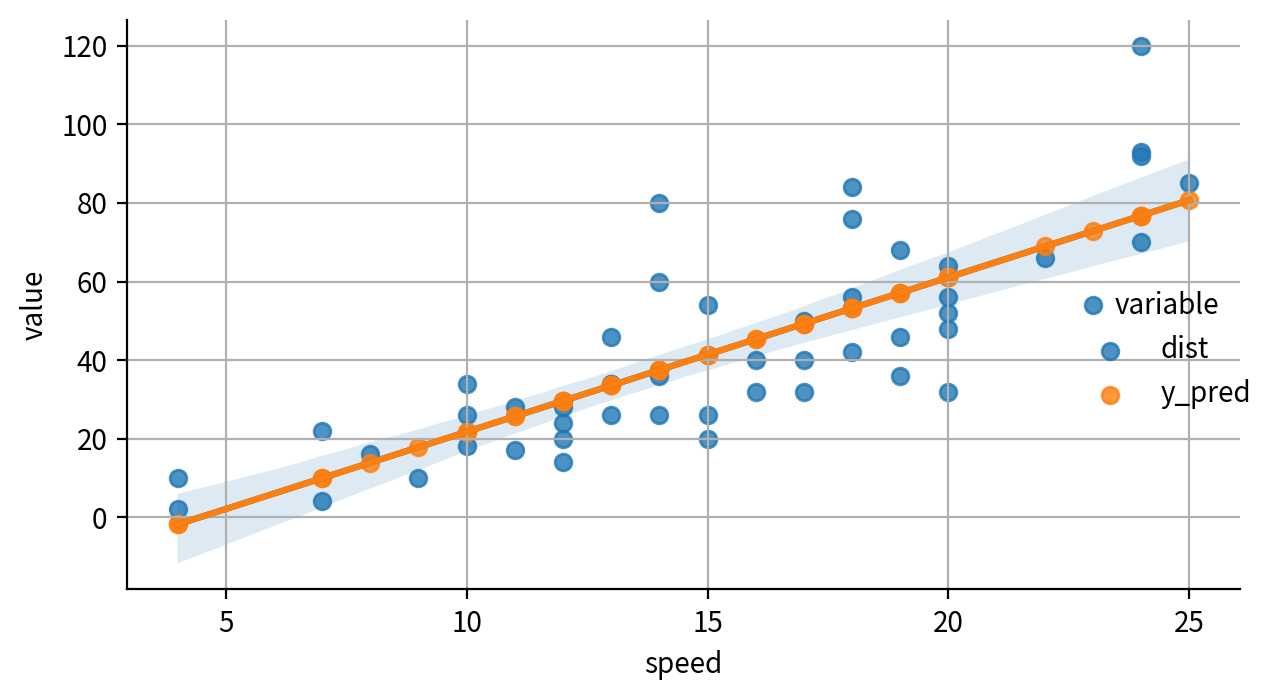

In [15]:
# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 720  # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
# 2) LM Plot 그리기
g = sb.lmplot(data=df_melt, x="speed", y="value", hue="variable")
g.fig.set_dpi(my_dpi)
g.fig.set_figwidth(figsize[0])
g.fig.set_figheight(figsize[1])
plt.grid()
# 3) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료